In [102]:
import pandas as pd

# Path to your Excel file
file_path = 'data/species_535.xlsx'

# Load only the first few rows to read column names
data_scfa = pd.read_excel(file_path, nrows=5, index_col=0)

## differet scfa producers, use different 
# Define your species of interest
scfa_species = ["Bacteroides", "Prevotella", "Coprococcus comes", "Veillonella", "Dialister", "Salmonella"]
#["Akkermansia muciniphila", "Bacteroides", "Ruminococcus", "Prevotella", "Escherichia coli", "Fusobacterium",
               #"Lactobacillus"]
               # "Faecalibacterium prausnitzii", "Roseburia", "Anaerostipes caccae", "Butyrivibrio fibrisolvens", "Subdoligranulum variabile",
              # "Anaerotruncus colihominis", "Eubacterium limosum", "Coprococcus"]

# Find columns that contain any of the species names
#filtered_columns = [col for col in data_butyrate.columns if any(species in col for species in butyrate_species)]

filtered_indices = [i for i, col in enumerate(data_scfa.columns, start=1) if any(species in col for species in scfa_species)]

# Include the first column index (0) with the filtered indices
use_columns = [0] + filtered_indices

# Load the entire file with only the filtered columns, setting the first column as the index
propionate_data = pd.read_excel(file_path, usecols=use_columns, index_col=0)


In [104]:
columns_to_drop = propionate_data.filter(regex='virus|phage').columns

# Drop these columns from the DataFrame
propionate_data = propionate_data.drop(columns=columns_to_drop)

In [105]:
propionate_data

,Salmonella sp. 14,Salmonella sp.,Salmonella sp. SCFS4,Salmonella sp. 2018103,Salmonella sp. SSDFZ54,Salmonella sp. SJTUF14523,Salmonella sp. A7,Salmonella sp. A29-2,Salmonella sp. SJTUF14076,Salmonella sp. SJTUF14146,...,Prevotella melaninogenica,Prevotella nigrescens,Prevotella oris,Prevotella veroralis,Prevotella jejuni,Prevotella fusca,Prevotella scopos,Prevotella enoeca,Prevotella buccalis,Bacteroides sp. CBA7301
500,0,0,0,0,0,0,0,0,0,0,...,9590,2237,2692,2093,2803,5297,1276,3518,4611,997
513,0,0,0,0,0,0,0,0,0,0,...,183,72,30,84,80,41,24,72,56,830
515,0,0,0,0,0,0,0,0,0,0,...,442,76,106,52,123,123,43,126,64,1070
523,0,0,0,0,0,0,0,0,0,0,...,361,67,59,85,92,0,113,109,0,2408
573,0,0,0,0,0,0,0,0,0,0,...,313,84,102,73,94,135,40,163,186,1906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10991,0,0,0,0,0,0,0,0,0,0,...,126,83,0,140,0,0,0,0,51,1330
11005,0,0,0,0,0,0,0,0,0,0,...,88,0,27,0,78,139,0,0,0,422
11017,0,0,0,0,0,0,0,0,0,0,...,114,0,231,0,90,57,0,69,0,1606
11019,0,0,0,0,0,0,0,0,0,0,...,118,52,76,0,81,0,0,80,0,1388


In [106]:
propionate_data.to_excel('data/propionate_producing_species.xlsx')

In [ ]:
# change to different files scfa, acetate, propinate, butyrate

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
scfa_data = pd.read_excel("data/scfa_producing_species.xlsx", index_col=0)
food_data_spear = pd.read_csv('data/Summarized_Food_Categories_Only.csv', index_col=0)
participants_data = pd.read_csv('data/demo_535.csv', index_col=0)

NameError: name 'scfa_data' is not defined

In [47]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [48]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [49]:
def adjust_for_covariates(data, covariates):
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid
    return adjusted_data



# Adjust microbiome and diet data
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['BMI', 'FREG8_Age']])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['BMI', 'FREG8_Age']])


In [50]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [51]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


/Users/qd/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


In [52]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
significant_species = true_counts >= 8
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]


In [53]:
filtered_species_scfa

,Fish,Crustacean,Mollusk,Seafood_dishes,Poultry,Red_meat,Meat_dishes,Processed_meat,Dairy,Cruciferous_vegetables,Legumes,Mushroom,Fruits,Wholegrain,Chapati,Noodle_dishes,Deep_fried,Coffee,Tea
Salmonella sp. SSDFZ54,0.000512,-0.003527,-0.102300,-0.015346,-0.101420,-0.066213,-0.094593,-0.199509,-0.003513,-0.012373,-0.018436,-0.011844,-0.066039,0.084584,-0.718632,-0.079766,0.039846,-0.136084,-0.194346
Salmonella sp. SJTUF14523,0.009852,-0.090331,-0.253473,-0.013016,-0.120235,-0.077330,-0.099608,-0.234179,-0.003848,-0.034520,-0.052192,0.024131,-0.049380,0.055266,-0.541933,-0.028129,-0.022818,-0.207342,-0.126692
Salmonella sp. SJTUF14076,-0.004414,-0.088212,-0.087348,0.005970,0.040825,0.064229,0.095105,0.061422,0.052788,0.032883,-0.006006,0.068329,0.104391,-0.010999,0.666719,0.095906,-0.123493,0.056619,0.230480
Salmonella sp. JXY0409-18,0.014931,0.188271,0.375328,0.038581,0.123742,0.075796,0.094299,0.226812,-0.015787,0.001855,0.045007,-0.092743,-0.001979,-0.036379,0.200312,-0.022856,0.090397,0.198226,-0.002076
Lactobacillus acidophilus,-0.035888,-0.145959,-0.190329,-0.017230,-0.037530,0.008823,0.024137,-0.091185,0.006840,0.031978,0.036330,0.100588,0.125768,-0.009545,0.338631,0.065010,-0.111145,-0.032090,0.158968
Lactobacillus acetotolerans,0.004975,0.096007,0.224022,0.032800,0.137618,0.110213,0.127582,0.208100,0.025746,0.051814,0.027989,-0.005856,0.069135,-0.053613,0.538278,0.051751,0.002989,0.189807,0.136505
Lactobacillus sp. CBA3605,-0.022710,-0.204281,-0.356070,-0.038597,-0.072453,-0.030494,-0.030555,-0.132833,0.030083,0.044561,-0.031517,0.113217,0.046620,0.007501,0.213524,0.077766,-0.146038,-0.121293,0.124277
Lactobacillus sp. PV012,0.018786,0.017417,-0.070875,0.003364,-0.092430,-0.086692,-0.115137,-0.183895,-0.044557,-0.014006,-0.026638,-0.012604,-0.070126,0.060878,-0.749144,-0.101917,0.055716,-0.131421,-0.216009
Lactobacillus sp. PV034,-0.006976,0.038308,0.179580,0.014648,0.116979,0.109213,0.126670,0.198011,0.023712,0.023225,0.038468,-0.018383,0.046956,-0.073354,0.643154,0.073623,0.004475,0.164186,0.169238
Lactobacillus sp. PV037,0.001379,0.002767,0.090976,0.018378,0.096821,0.100873,0.126553,0.186853,0.016227,0.015109,0.011052,0.025760,0.077115,-0.047814,0.727166,0.089018,-0.037474,0.137477,0.216086


In [54]:
## drop phage and virus

<Figure size 1440x1440 with 0 Axes>

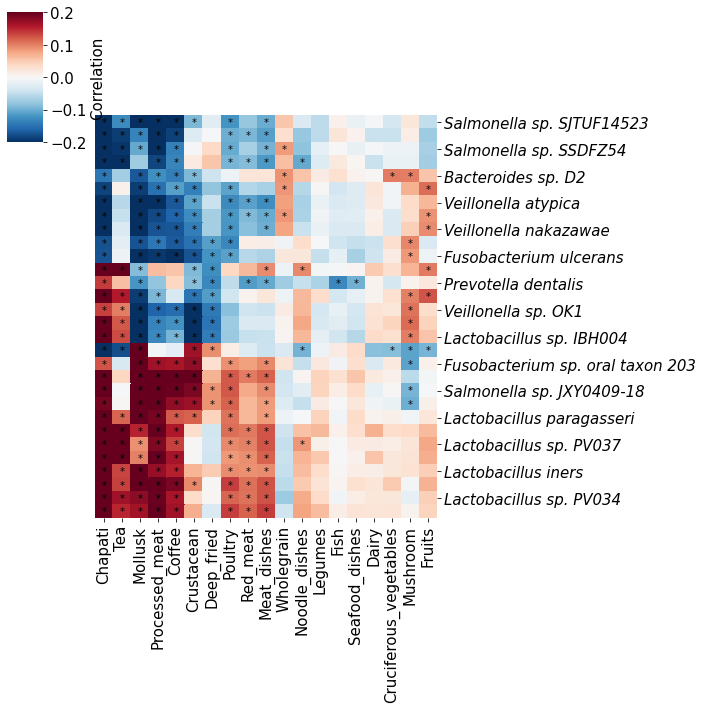

In [57]:
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)


plt.figure(figsize=(20, 20))
ax = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=True)

ax.ax_row_dendrogram.set_visible(False)
ax.ax_col_dendrogram.set_visible(False)

row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new position in the clustered heatmap
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.rc('font', size=15)
plt.rc('axes', labelsize=15)
plt.rc('axes', titlesize=15)

plt.show()

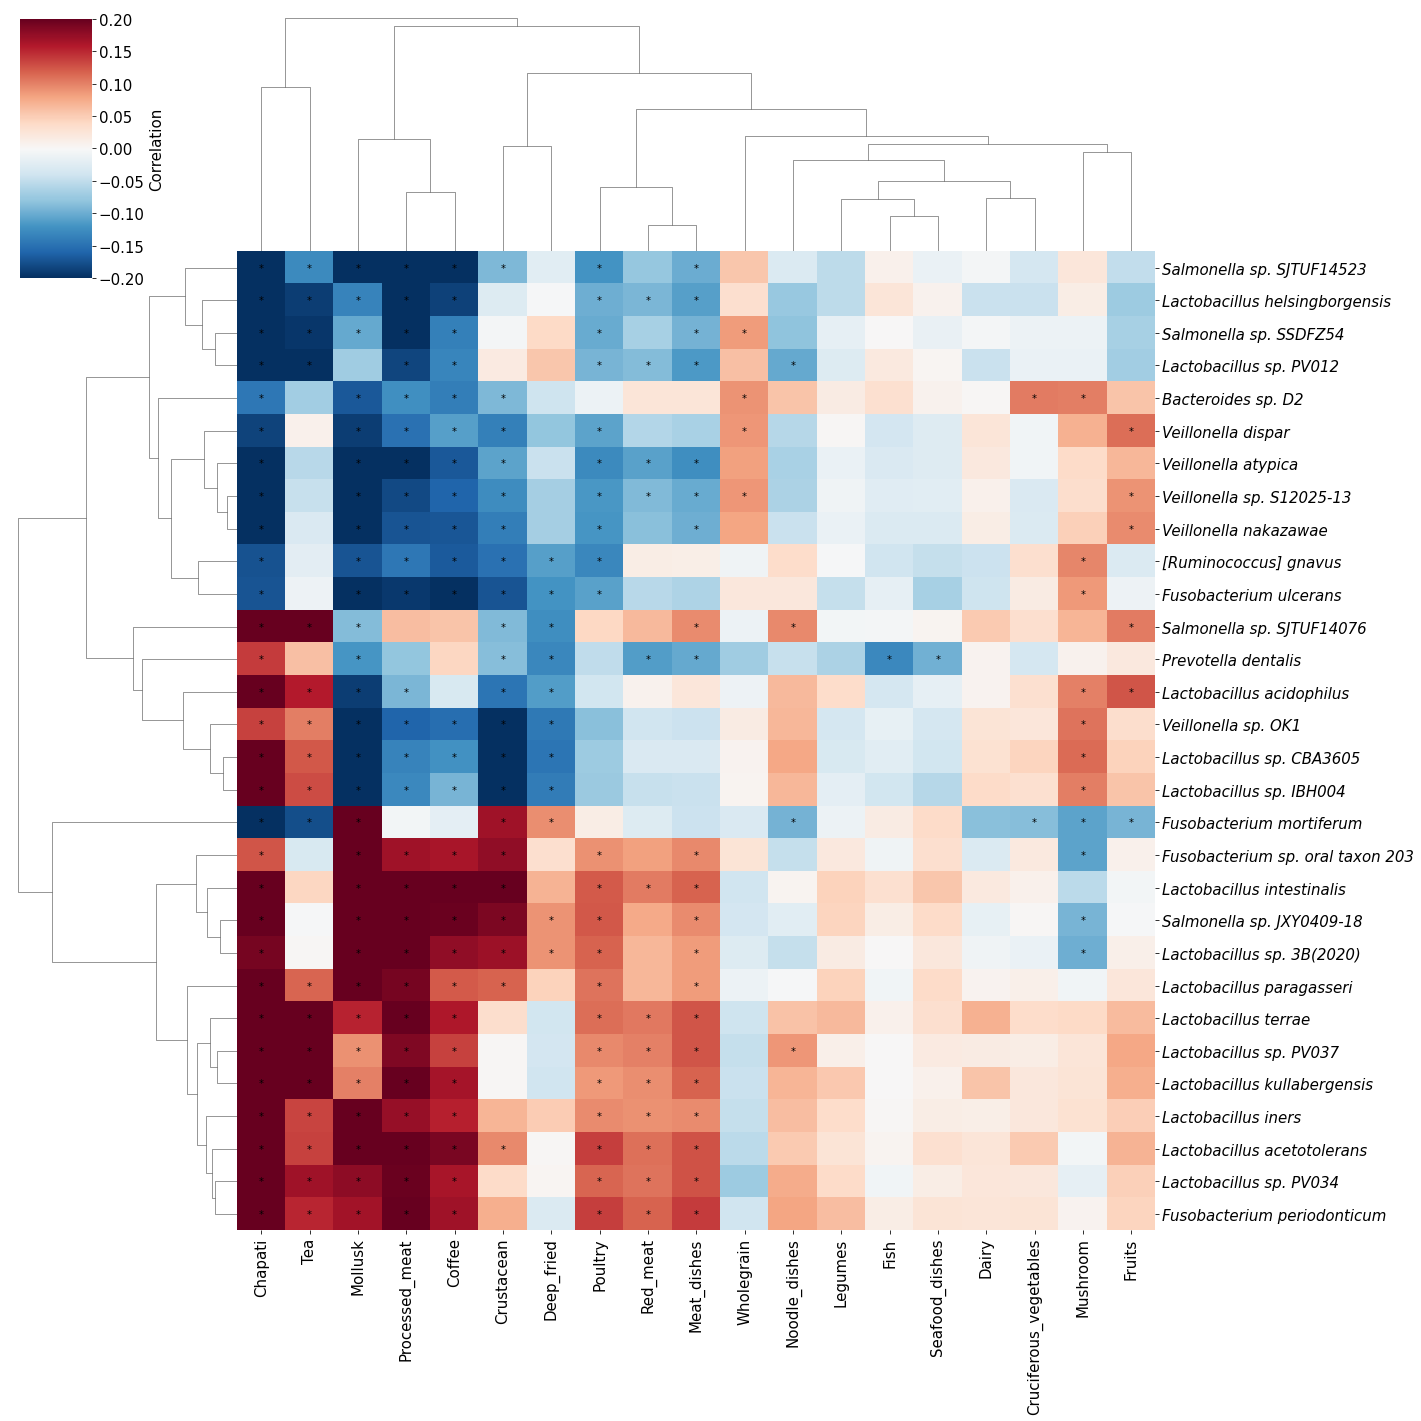

In [60]:


# Assuming filtered_species_scfa, significant_matrix_scfa are defined as per your context
# Clipping values
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=True,
    col_cluster=True,
    figsize=(20, 20)  # Adjust size directly here if needed
)

# Making dendrograms visible to check the layout
ax.ax_row_dendrogram.set_visible(True)
ax.ax_col_dendrogram.set_visible(True)

# Get the order of rows and columns after clustering
row_order = ax.dendrogram_row.reordered_ind
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_i = row_order.index(i)
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})
#plt.savefig('figure/food_scfa_heatmap.png', format='png', dpi=300, bbox_inches='tight')
plt.show()


In [61]:
#ordered_indices = ax.dendrogram_row.reordered_ind

# Print the ordered row names
#ordered_row_names = clipped_correlations_scfa.index[ordered_indices]
#print(ordered_row_names)
food_row_order = ax.dendrogram_row.reordered_ind

In [ ]:
#nutrition

In [62]:
scfa_data = pd.read_excel("data/scfa_producing_species.xlsx", index_col=0)
food_data_spear = pd.read_csv('data/nutrition_535.csv', index_col=0)
participants_data = pd.read_csv('data/demo_535.csv', index_col=0)

In [63]:
common_indices = scfa_data.index.intersection(food_data_spear.index)
scfa_data = scfa_data.loc[common_indices]
food_data_spear = food_data_spear.loc[common_indices]
participants_data = participants_data.loc[common_indices]

In [64]:
# Convert data to numeric and handle non-numeric entries
scfa_data = scfa_data.apply(pd.to_numeric, errors='coerce')
food_data_spear = food_data_spear.apply(pd.to_numeric, errors='coerce')
participants_data['BMI'] = pd.to_numeric(participants_data['BMI'], errors='coerce')
participants_data['FREG8_Age'] = pd.to_numeric(participants_data['FREG8_Age'], errors='coerce')

In [65]:
def adjust_for_covariates(data, covariates):
    adjusted_data = pd.DataFrame(index=data.index, columns=data.columns)
    covariates = sm.add_constant(covariates)  # Add a constant to the model
    for column in data.columns:
        # Drop rows where NaN exists in the current column or in covariates
        combined = pd.concat([data[column], covariates], axis=1).dropna()
        model = sm.OLS(combined[column], combined[covariates.columns]).fit()
        adjusted_data.loc[combined.index, column] = model.resid
    return adjusted_data



# Adjust microbiome and diet data
adjusted_scfa_data = adjust_for_covariates(scfa_data, participants_data[['BMI', 'FREG8_Age']])
adjusted_food_spear = adjust_for_covariates(food_data_spear, participants_data[['BMI', 'FREG8_Age']])


In [66]:
correlations_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)
p_values_scfa = pd.DataFrame(index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)


# Ensure the data is numeric and handle NaNs appropriately
correlations_scfa = correlations_scfa.astype(float)  # Convert to float
p_values_scfa = p_values_scfa.astype(float)  # Convert to float

# Example to handle NaNs in correlations if necessary
correlations_scfa.fillna(0, inplace=True)  # Replace NaNs with zero or some other appropriate value


In [67]:
for microbe in adjusted_scfa_data.columns:
    for nutrient in adjusted_food_spear.columns:
        # Drop NaN values from both columns before correlation
        valid_indices = adjusted_scfa_data[microbe].notna() & adjusted_food_spear[nutrient].notna()
        if valid_indices.any():  # Check if there are any valid pairs left
            corr, pval = spearmanr(adjusted_scfa_data[microbe][valid_indices], adjusted_food_spear[nutrient][valid_indices])
            correlations_scfa.loc[microbe, nutrient] = corr
            p_values_scfa.loc[microbe, nutrient] = pval
        else:
            correlations_scfa.loc[microbe, nutrient] = np.nan
            p_values_scfa.loc[microbe, nutrient] = np.nan

#significant_matrix_spear, corrected_pvals_spear, _, _ = multipletests(p_values_spear.values.flatten(), alpha=0.2, method='fdr_bh')


#significant_matrix_spear = significant_matrix_spear.reshape(p_values_spear.shape)


/Users/qd/opt/anaconda3/lib/python3.8/site-packages/scipy/stats/stats.py:4264: SpearmanRConstantInputWarning: An input array is constant; the correlation coefficent is not defined.
  warnings.warn(SpearmanRConstantInputWarning())


In [68]:
p_flat = p_values_scfa.values.flatten()
reject, corrected_pvals_scfa, _, _ = multipletests(p_flat, alpha=0.2, method='fdr_bh')
significant_matrix_scfa = pd.DataFrame(reject.reshape(p_values_scfa.shape), index=adjusted_scfa_data.columns, columns=adjusted_food_spear.columns)

# Summing the significant correlations per microbe
true_counts = significant_matrix_scfa.sum(axis=1)

# Filter species with at least 10 significant correlations
#significant_species = true_counts >= 0
filtered_species_scfa = correlations_scfa.loc[significant_species.index[significant_species]]
#significant_species

filtered_species_scfa = filtered_species_scfa.iloc[food_row_order, :]
filtered_species_scfa

,Water,Energy,Protein,Total_fat,Saturated_fatty_acid,MUFA,PUFA,CHO,starch,sugar,...,transfat,Bcarotene,Retinol,Thiamin,Riboflavin,Folate,VitaminB12,Potassium,Magnesium,Zinc
Salmonella sp. SJTUF14523,0.075829,-0.005008,0.003861,-0.002927,0.002549,-0.005960,-0.009235,-0.015270,-0.019442,0.009962,...,0.212089,-0.039798,0.017832,-0.003258,0.017429,-0.026401,0.072854,-0.013212,0.115963,0.015026
Lactobacillus helsingborgensis,0.025600,-0.047635,-0.029926,-0.027039,-0.028245,-0.018784,-0.031921,-0.065925,-0.067619,-0.030824,...,-0.036866,-0.055585,-0.024968,-0.053189,-0.022716,0.016075,0.086602,-0.051260,-0.203536,-0.018216
Salmonella sp. SSDFZ54,-0.008908,-0.002882,0.004987,0.005108,0.007790,0.003550,0.007506,-0.014602,-0.022254,0.018468,...,-0.120463,-0.016221,-0.013979,0.001980,0.032142,0.008461,0.047393,-0.007571,-0.292080,0.020404
Lactobacillus sp. PV012,-0.038161,-0.028117,-0.016358,-0.011138,-0.010420,-0.007514,-0.012513,-0.042489,-0.046270,-0.007997,...,-0.230785,-0.024388,-0.068354,-0.034209,-0.001045,-0.001171,0.039702,-0.030422,-0.438821,-0.002266
Bacteroides sp. D2,-0.030439,-0.020354,-0.003662,-0.003486,-0.007526,0.001609,-0.001607,-0.033030,-0.021719,-0.026636,...,0.125873,0.013355,-0.158716,0.028504,-0.006653,-0.120371,-0.136769,-0.013001,0.160350,-0.016014
Veillonella dispar,0.030470,0.021558,0.012919,0.005638,-0.006713,-0.003927,0.045464,0.036618,0.015888,0.067147,...,0.145739,0.002870,-0.060940,0.030660,0.025448,-0.054036,-0.033568,0.032980,0.149361,0.046708
Veillonella atypica,0.029422,-0.004509,-0.006854,-0.013741,-0.022482,-0.021718,0.018633,0.000840,-0.024505,0.049420,...,0.141254,0.002836,-0.081007,0.000631,0.012112,-0.074026,-0.027234,0.012109,0.073563,0.018406
Veillonella sp. S12025-13,0.029592,0.010475,0.007423,0.001209,-0.009294,-0.009422,0.038680,0.016668,-0.004706,0.049077,...,0.121187,-0.020549,-0.052664,0.017523,0.018478,-0.058382,-0.041814,0.015619,0.068092,0.039562
Veillonella nakazawae,0.002651,0.015563,0.009287,0.005647,-0.001150,-0.007690,0.039994,0.022145,0.000871,0.054306,...,0.139543,-0.015371,-0.069325,0.018477,0.018061,-0.082394,-0.082333,0.018023,0.111478,0.038034
[Ruminococcus] gnavus,-0.011251,-0.057403,-0.055407,-0.059551,-0.064903,-0.048450,-0.065327,-0.046850,-0.027184,-0.061623,...,0.348196,-0.036550,-0.010003,-0.052700,-0.069451,-0.130651,-0.092120,-0.087000,0.377695,-0.050061


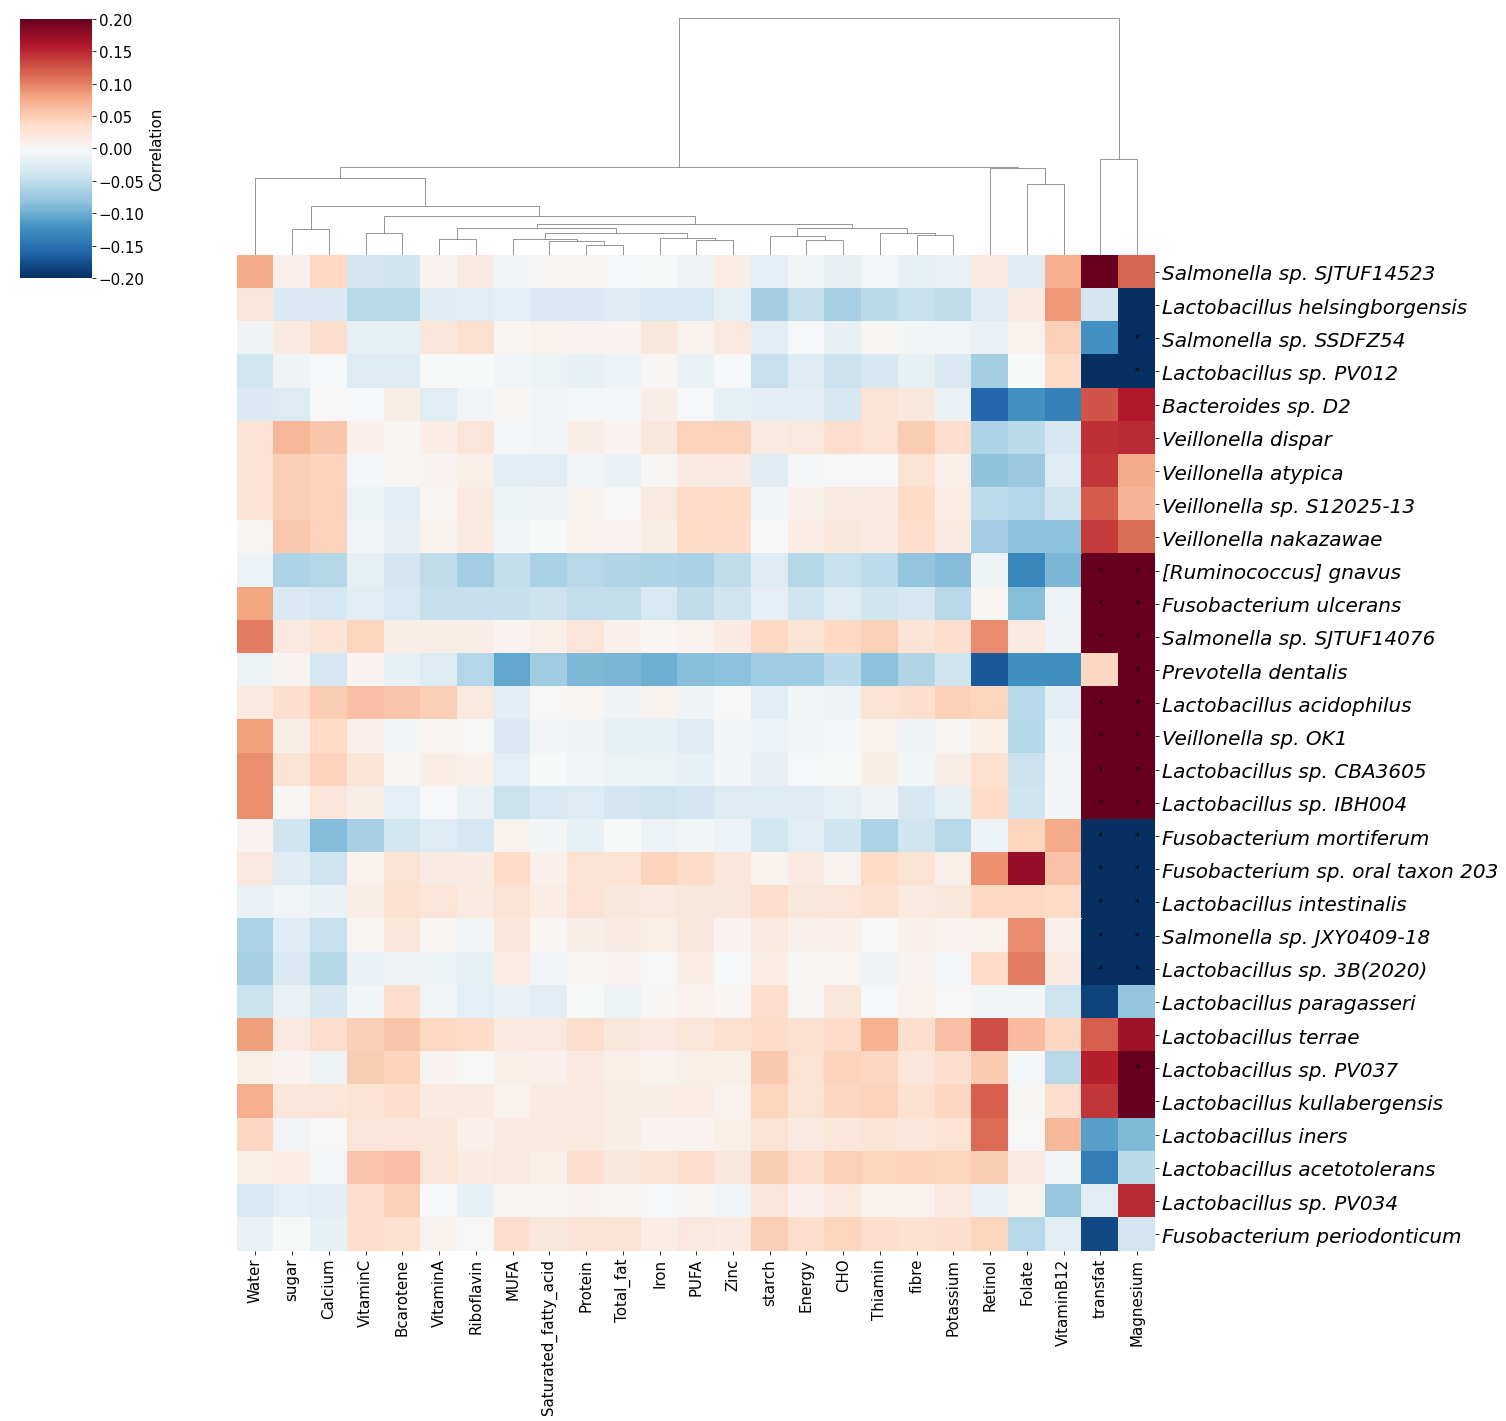

In [73]:
filtered_significance_matrix_scfa = significant_matrix_scfa.loc[filtered_species_scfa.index, filtered_species_scfa.columns]


clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Setup figure settings beforehand
plt.rc('font', size=15)  # Adjusting global font size
plt.rc('axes', labelsize=15, titlesize=15)  # Adjusting label and title sizes

# Create clustermap with rows in fixed order
ax = sns.clustermap(
    clipped_correlations_scfa,
    cmap="RdBu_r",
    annot=False,
    cbar_kws={'label': 'Correlation'},
    vmin=-0.2,
    vmax=0.2,
    row_cluster=False,  # Disable row clustering
    col_cluster=True,   # Enable column clustering if desired
    figsize=(20, 20)    # Adjust size directly here if needed
)

# Since row clustering is disabled, row order is unchanged, retrieve column order
col_order = ax.dendrogram_col.reordered_ind

# Highlight significant cells (adjusted for column clustering only)
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        new_j = col_order.index(j)
        ax.ax_heatmap.text(new_j + 0.5, i + 0.5, '*', ha='center', va='center', color='black', size=10)

# Adjust y-tick labels
y_labels = [label.get_text() for label in ax.ax_heatmap.get_yticklabels()]
ax.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic', 'fontsize': 20})

plt.savefig('figure/nutrition_scfa_heatmap.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

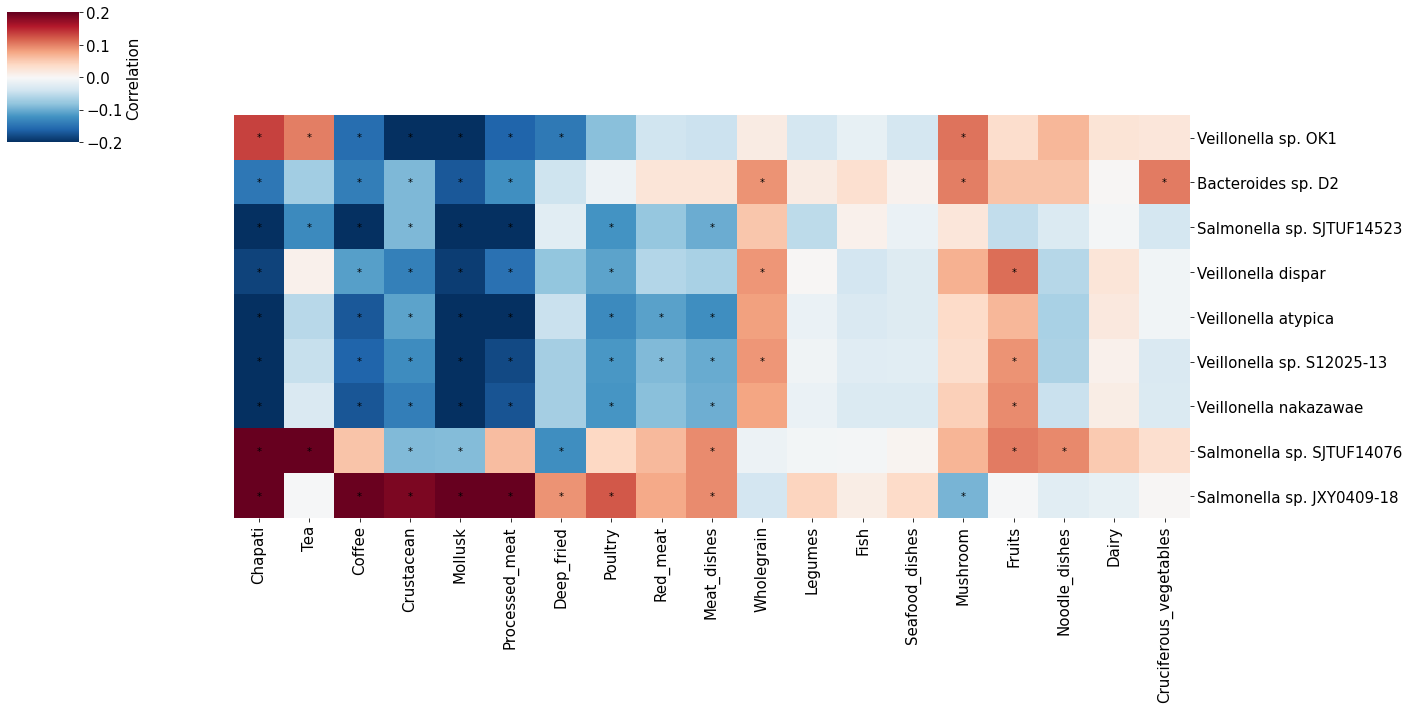

In [127]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar_kws={'label': 'Correlation'}, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(20, 10))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)


# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

plt.show()


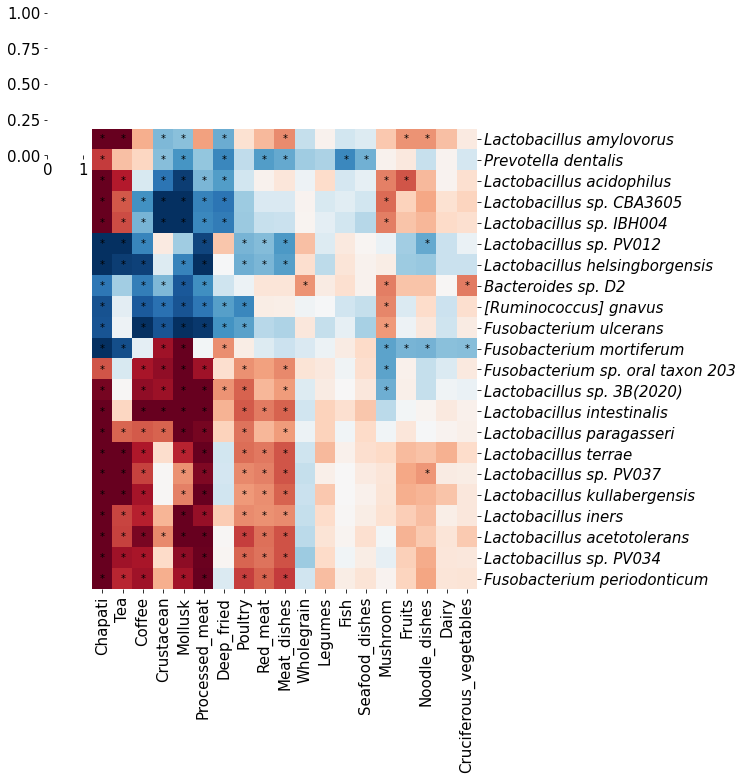

In [35]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Custom column order
custom_order = [
    'Chapati', 'Tea', 'Coffee', 'Crustacean', 'Mollusk', 'Processed_meat',
    'Deep_fried', 'Poultry', 'Red_meat', 'Meat_dishes', 'Wholegrain',
    'Legumes', 'Fish', 'Seafood_dishes', 'Mushroom', 'Fruits',
    'Noodle_dishes', 'Dairy', 'Cruciferous_vegetables'
]

# Reorder the data and significance matrix according to the custom order
filtered_species_scfa = filtered_species_scfa[custom_order]
filtered_significance_matrix_scfa = filtered_significance_matrix_scfa[custom_order]

# Clip the correlations as before
clipped_correlations_scfa = np.clip(filtered_species_scfa, -0.2, 0.2)

# Create a clustermap with row clustering only, no color bar, trying to make it more square-like
cluster_grid = sns.clustermap(clipped_correlations_scfa, cmap="RdBu_r", annot=False, cbar=False, vmin=-0.2, vmax=0.2, row_cluster=True, col_cluster=False, figsize=(10, 11), dendrogram_ratio=(.1, .2))

# Hide the dendrogram for columns
cluster_grid.ax_col_dendrogram.set_visible(False)
cluster_grid.ax_row_dendrogram.set_visible(False)

# Retrieve the new order of rows after clustering
row_order = cluster_grid.dendrogram_row.reordered_ind

# Annotating with significance marks, taking into account the new row order
for (i, j), significant in np.ndenumerate(filtered_significance_matrix_scfa):
    if significant:
        # Find the new row position in the clustered heatmap
        new_i = row_order.index(i)
        cluster_grid.ax_heatmap.text(j + 0.5, new_i + 0.5, '*', ha='center', va='center', color='black', size=10)

y_labels = [label.get_text() for label in cluster_grid.ax_heatmap.get_yticklabels()]

# Set the y-axis labels to italicized text
cluster_grid.ax_heatmap.set_yticklabels(y_labels, fontdict={'fontstyle': 'italic'})
plt.show()


In [ ]:
## not just for scfa